In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker
import requests
import osmnx as ox

# Configurazione stile grafico del report

# Global
sns.set_theme(style="whitegrid")

# Parametri leggibilità PDF
plt.rcParams.update({
    'font.size' : 12,
    'axes.titlesize' : 18,
    'axes.titleweight' : 'bold',
    'axes.labelsize' : 14,
    'axes.labelweight' : 'bold',
    'xtick.labelsize' : 12,
    'ytick.labelsize' : 12,
    'axes.spines.top' : False,
    'axes.spines.right' : False,
    'axes.grid' : True,
    'grid.alpha' : 0.2,
    'grid.linestyle' : '--'
})

# Palette Accessibile Daltonismo
palette_territorio = {
    'Riposto': '#0072B2',        # Blue
    'Zafferana Etnea': '#009E73', # Bluish Green (Accessibile)
    'Giardini-Naxos': '#D55E00'   # Vermillion (Accessibile)
}

# Funzione rapida epr applicare la palette ai grafici a barre
def get_palette(order_list):
    return[palette_territorio[city] for city in order_list]

In [28]:
# Caricamento Dataset
df_sicilia = pd.read_csv(r"sample_data.csv")

def clean_price(series):
    return pd.to_numeric(
        series.astype(str).str.replace(r'[$,€]', '', regex = True).str.replace(',', '').str.strip(),
        errors = 'coerce'
    )
df_sicilia['price'] = clean_price(df_sicilia['price'])
df_sicilia = df_sicilia.dropna(subset = ['price']) # Droppiamo gli NA per evitare che la sostituzione non restituisca valori "veritieri"

In [29]:
# Creazione dei Subset Strategici

riposto_raw = df_sicilia[df_sicilia['neighbourhood_cleansed'].str.contains('Riposto', case=False)].copy()
giardini_raw = df_sicilia[df_sicilia['neighbourhood_cleansed'].str.contains('Giardini-Naxos', case=False)].copy()
zafferana_raw = df_sicilia[df_sicilia['neighbourhood_cleansed'].str.contains('Zafferana Etnea', case=False)].copy()


# Taglio degli outlier
def trim_outliers(group):
    q1 = group['price'].quantile(0.25)
    q3 = group['price'].quantile(0.75)
    iqr = q3 - q1

    # Definiamo il limite superiore (Il baffo per il boxplot)
    upper_bound = q3 + (3 * iqr) # Turqkey Extreme Method

    return group[group['price'] <= upper_bound].copy()

# Per coerenza Applichiamo il trimming a ciascuno dei subset
riposto_df = trim_outliers(riposto_raw)
giardini_df = trim_outliers(giardini_raw)
zafferana_df = trim_outliers(zafferana_raw)

# Calcoliamo i KPI di base per un confronto rapido
for d in [riposto_df, giardini_df, zafferana_df]:
    d.loc[:, 'estimated_revenue_annuo'] = (d['number_of_reviews_ltm'] * 2) * 3 * d['price'] # San Francisco Model

print("Dataframes pronti: Riposto, Giardini Naxos, Zafferana Etnea.")

Dataframes pronti: Riposto, Giardini Naxos, Zafferana Etnea.


In [30]:
# Calcoliamo i KPI aggregati per Riposto
tot_listing = len(riposto_df)
avg_price = riposto_df['price'].mean()
total_est_revenue = riposto_df['estimated_revenue_annuo'].sum()

print(f'--- ANALISI VOLUMETRICA RIPOSTO 2025 ---')
print(f'Alloggi attivi: {tot_listing}')
print(f'Prezzo medio notte: {avg_price:.2f}€')
print(f'Fatturato annuo stimato (indotto diretto): {total_est_revenue:.2f}€')

--- ANALISI VOLUMETRICA RIPOSTO 2025 ---
Alloggi attivi: 33
Prezzo medio notte: 139.62€
Fatturato annuo stimato (indotto diretto): 812983.08€


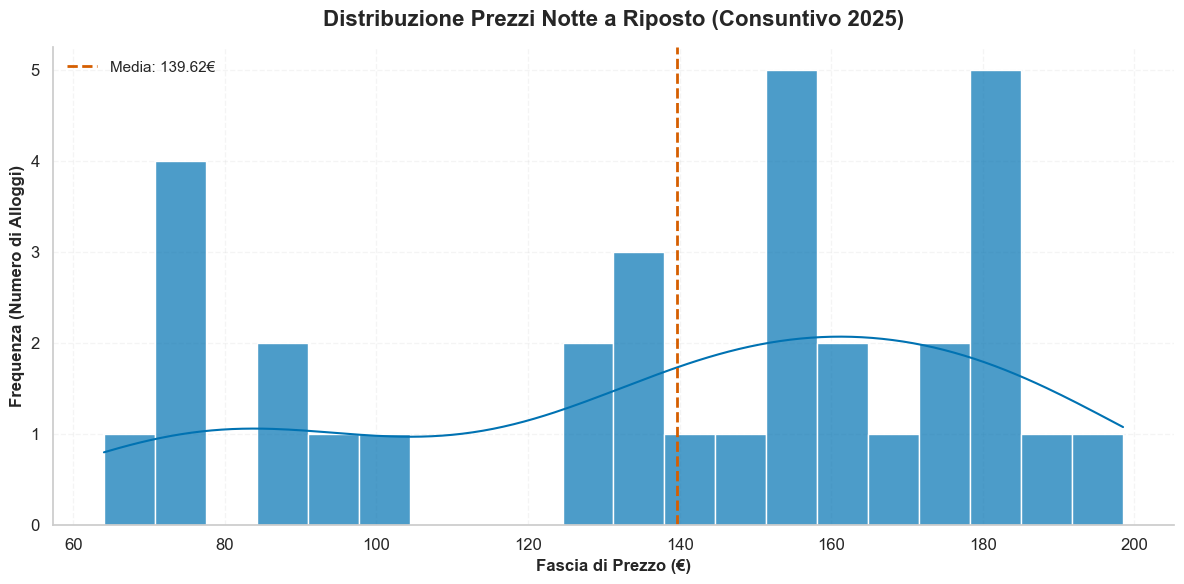

In [31]:
# Realizzazione dell'Istogramma
plt.figure(figsize=(12, 6))
sns.histplot(riposto_df['price'],
             kde = True,
             color = palette_territorio['Riposto'],
             bins = 20,
             alpha = 0.7,   # Leggera trasparenza
             edgecolor = 'w' # Bordi bianchi sottili tra le barre
)

# Linea Media
plt.axvline(riposto_df['price'].mean(), 
            color = '#D55E00', 
            linestyle = '--',
            linewidth = 2,
            label = f"Media: {riposto_df['price'].mean():.2f}€")

# Elementi Grafico
plt.title('Distribuzione Prezzi Notte a Riposto (Consuntivo 2025)', fontsize = 16, fontweight = 'bold', pad = 15)
plt.xlabel('Fascia di Prezzo (€)', fontsize = 12)
plt.ylabel('Frequenza (Numero di Alloggi)', fontsize = 12)

# Legenda pulita
plt.legend(frameon = False)

sns.despine()
plt.tight_layout()
plt.savefig('distribuzione_prezzi_riposto.png', dpi = 300)
plt.show()

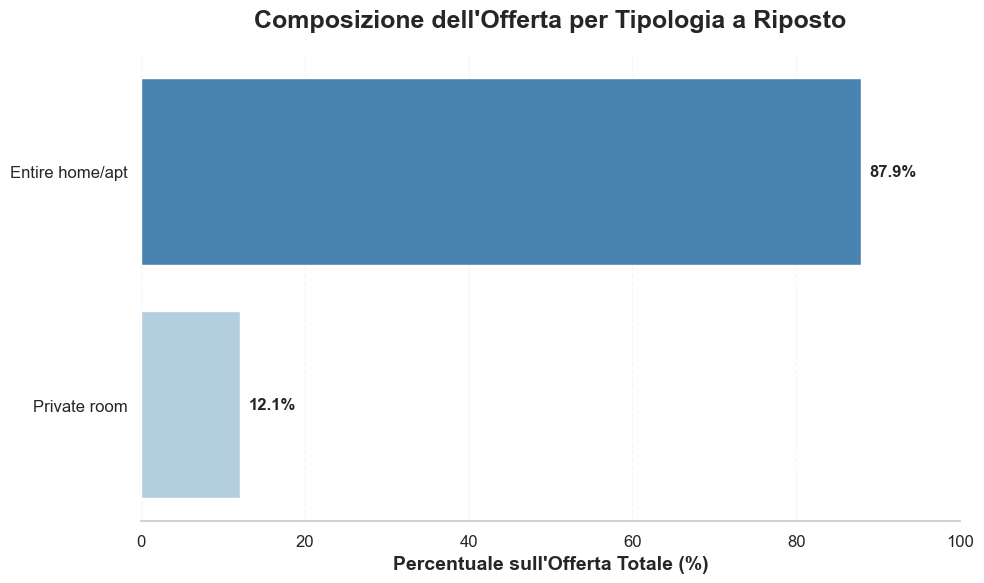

In [32]:
# Conteggio e percentuale tipologie

plt.figure(figsize = (10,6))

# Calcolo Percentuali
tipo_offerta_riposto = riposto_df['room_type'].value_counts(normalize = True) * 100

# Grafico a barre orizzontali
ax = sns.barplot(
    x = tipo_offerta_riposto.values,
    y = tipo_offerta_riposto.index,
    palette = "Blues_r", # Gradiente del blu
    hue = tipo_offerta_riposto.index,
    legend = False
)

# Aggiungiamo le etichette alle barre
for i,v in enumerate(tipo_offerta_riposto):
    ax.text(v + 1, i, f'{v:.1f}%', va = 'center', fontweight = 'bold', fontsize = 12)

# Titoli e Labels
plt.title("Composizione dell'Offerta per Tipologia a Riposto", pad = 20)
plt.xlabel("Percentuale sull'Offerta Totale (%)")
plt.ylabel('')

# Limite X per dare spazio alle etichette di testo
plt.xlim(0, 100)

sns.despine(left = True, bottom = False)
plt.tight_layout()

plt.savefig("composizione_offerta_tipologia_riposto.png", dpi = 300)

plt.show()

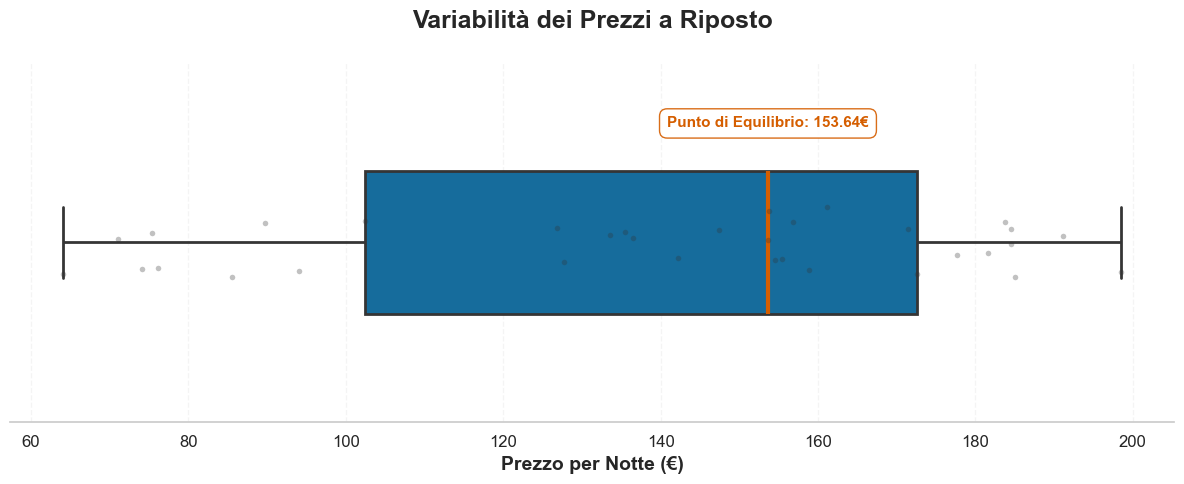

In [33]:
# Calcoliamo la mediana (50° percentile)
mediana_riposto = riposto_df['price'].median()

plt.figure(figsize = (12, 5))

sns.boxplot(
    x = riposto_df['price'], 
    color = palette_territorio['Riposto'], 
    width = 0.4, 
    linewidth = 2, 
    fliersize = 0, 
    medianprops = {'color' : '#D55E00', 'linewidth' : 3, 'linestyle' : '-'}
)

# Aggiungiamo i punti per dare profondità al dato
sns.stripplot(
    x = riposto_df['price'], 
    color = '#333333',
    alpha = 0.3, 
    size = 4,
    jitter = True
)

# Annotazione della mediana sul Grafico
plt.text(
    mediana_riposto, -0.32, f'Punto di Equilibrio: {mediana_riposto:.2f}€',
    color = '#D55E00', 
    fontweight = 'bold',
    ha = 'center', 
    fontsize = 11,
    bbox = dict(facecolor = 'white', edgecolor = '#D55E00', boxstyle = 'round,pad=0.5', alpha = 0.9)
)

    
plt.title('Variabilità dei Prezzi a Riposto', pad = 25)
plt.xlabel('Prezzo per Notte (€)')

# Estetica
sns.despine(left = True)
plt.yticks([]) # Nasconde l'asse Y
plt.tight_layout()

plt.savefig('boxplot_prezzi_focus_mediana.png', dpi = 300, bbox_inches = 'tight')
plt.show()

In [34]:
q1 = riposto_df['price'].quantile(0.25)
q3 = riposto_df['price'].quantile(0.75)
iqr = q3 - q1 # Interquartile Range

print(f"--- ANALISI DEI SEGMENTI DI PREZZO ---")
print(f"Soglia Segmento Entry-Level (Q1): {q1:.2f}€")
print(f"Soglia Segmento Premium (Q3): {q3:.2f}€")
print(f"Ampiezza del 'Cuore del Mercato' (IQR): {iqr:.2f}€")

print(f"\nInterpretazione: Il 50% centrale degli alloggi a Riposto opera in una fascia di prezzo tra {q1:.2f}€ e {q3:.2f}€.")

--- ANALISI DEI SEGMENTI DI PREZZO ---
Soglia Segmento Entry-Level (Q1): 102.38€
Soglia Segmento Premium (Q3): 172.58€
Ampiezza del 'Cuore del Mercato' (IQR): 70.20€

Interpretazione: Il 50% centrale degli alloggi a Riposto opera in una fascia di prezzo tra 102.38€ e 172.58€.


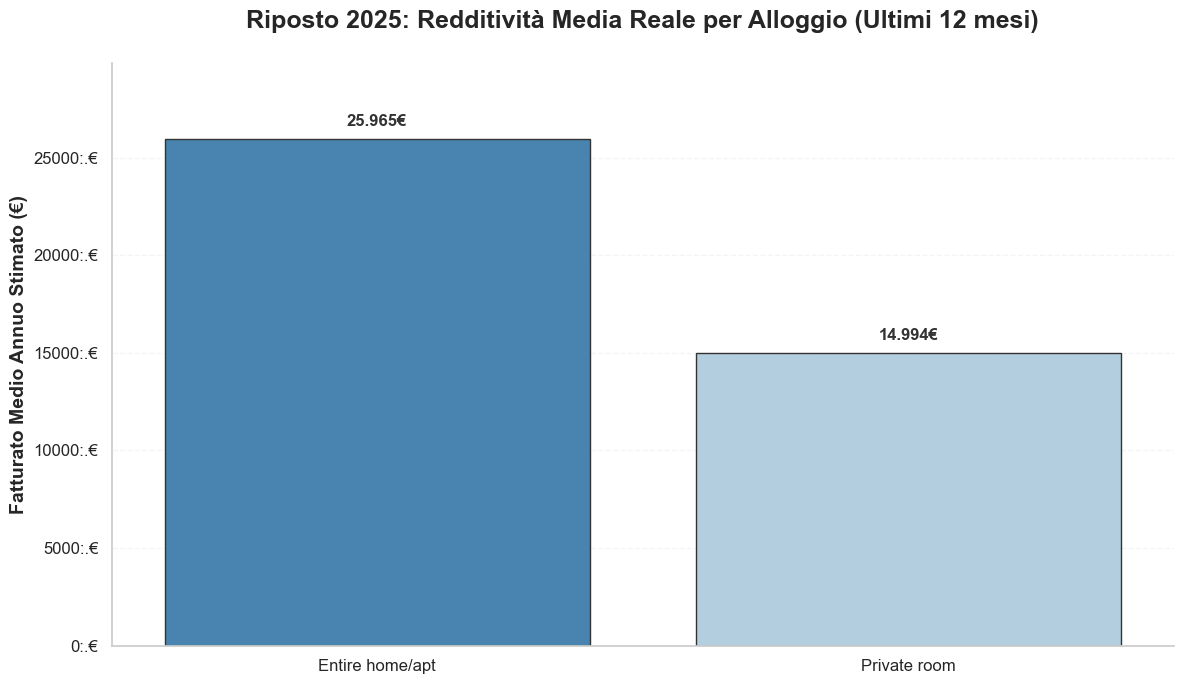

--- EFFICIENZA MEDIA ANNUA REALE (Dati LTM 2025) ---
                 prezzo_medio  revenue_annuo_medio  numero_alloggi
room_type                                                         
Entire home/apt        141.65             25965.73              29
Private room           124.88             14994.26               4


In [35]:
# Calcolo dell'efficienza REALE (basata sugli ultimi 12 mesi)
performance_annuale = riposto_df.groupby('room_type').agg(
    prezzo_medio=('price', 'mean'),
    revenue_annuo_medio=('estimated_revenue_annuo', 'mean'),
    numero_alloggi=('price', 'count')
).sort_values(by='revenue_annuo_medio', ascending=False)


# 2. Visualizzazione
plt.figure(figsize=(12, 7))

# Usiamo performance_annuale e la colonna corretta revenue_annuo_medio
ax = sns.barplot(
    x=performance_annuale.index,
    y=performance_annuale['revenue_annuo_medio'],
    palette='Blues_r',
    hue=performance_annuale.index,
    legend=False,
    edgecolor='.2'
)

# Etichette Dinamiche (Sopra le barre)
for p in ax.patches:
    height = p.get_height() 
    if height > 0:
        # Formattazione italiana: 1.250€
        label_text = f"{int(height):,}".replace(',', '.') + '€'
        
        ax.text(
            p.get_x() + p.get_width() / 2., 
            height + (performance_annuale['revenue_annuo_medio'].max() * 0.02), # Padding dinamico
            label_text, 
            ha = 'center', 
            va = 'bottom', 
            fontsize = 12, 
            fontweight = 'bold', 
            color = '#333333'
        )

# Titoli e Label
plt.title('Riposto 2025: Redditività Media Reale per Alloggio (Ultimi 12 mesi)', 
          pad=25)
plt.ylabel('Fatturato Medio Annuo Stimato (€)')
plt.xlabel('')

# Formattazione asse Y
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: f"{int(x)}:,".replace(',','.') + '€'))

#Elevazione Limite di Y per non far toccare il testo al bordo superiore
plt.ylim(0, performance_annuale['revenue_annuo_medio'].max() * 1.15)

sns.despine()
plt.tight_layout()
plt.savefig('redditivita_annua_riposto_tipologia.png', dpi = 300, bbox_inches = 'tight')

plt.show()

print("--- EFFICIENZA MEDIA ANNUA REALE (Dati LTM 2025) ---")
print(performance_annuale.round(2))

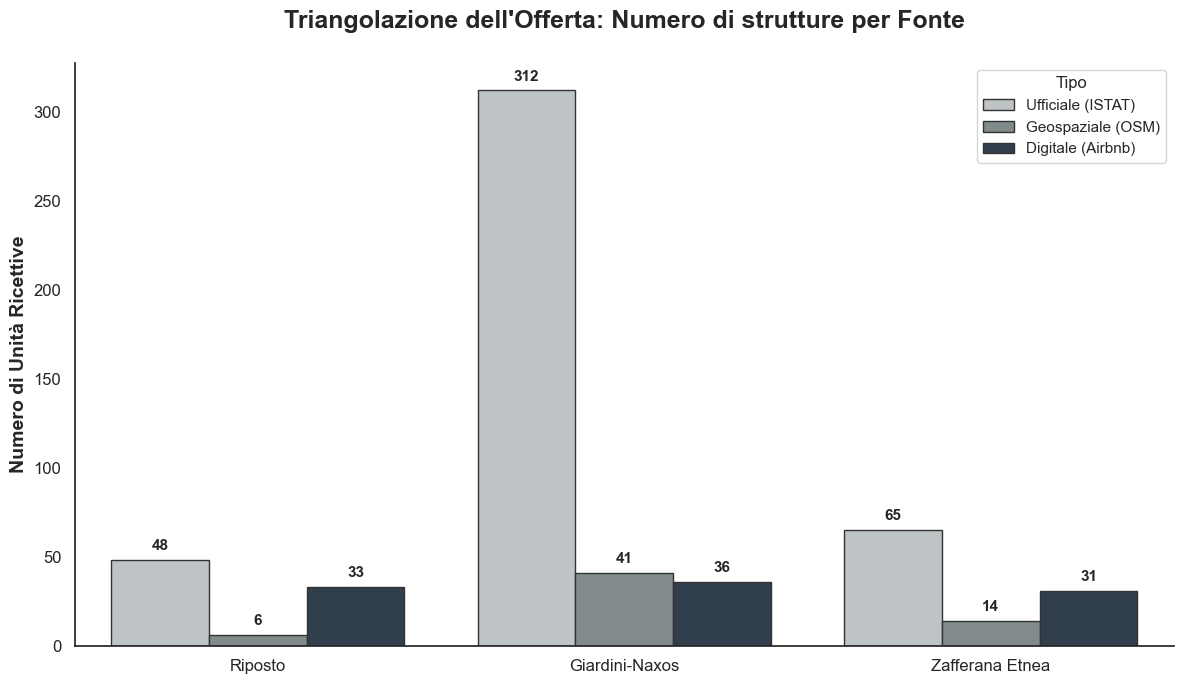


      TABELLA RIASSUNTIVA: TRIANGOLAZIONE UNITÀ RICETTIVE (2025)      
 Ufficiale (ISTAT)  Geospaziale (OSM)  Digitale (Airbnb) Incidenza Digitale %
                48                  6                 33               68.75%
               312                 41                 36               11.54%
                65                 14                 31               47.69%



In [43]:
# -- Funzione di Scraping --
def get_osm_counts(city_name):
    tags = {"tourism": ["hotel", "guest_house", "hostel", "motel", 
            "bed_and_breakfast", "apartment", "resort"]}
    # Scarichiamo i POI per l'area del comune
    try:
        pois = ox.features_from_place(f"{city_name}, Italy", tags)
        
        # Pulizia: se non troviamo nulla
        return 0 if pois.empty else pois['tourism'].count()
        
    except Exception as e:
        print({f"Errore nel recupero dati OSM per {city_name}": e})
        return 0

# -- Preparazione dati -- 
cities = ["Riposto", "Giardini-Naxos", "Zafferana Etnea"]
osm_counts = [get_osm_counts(city) for city in cities]
airbnb_counts = [len(riposto_df), len(giardini_df), len(zafferana_df)]
istat_counts = [48, 312, 65] # Dati ufficiali di input

# -- Df Riassuntivo --
df_riassunto = pd.DataFrame({
    'Ufficiale (ISTAT)': istat_counts,
    'Geospaziale (OSM)': osm_counts,
    'Digitale (Airbnb)': airbnb_counts
})

# Calcoliamo l'Incidenza Digitale nella tabella
df_riassunto['Incidenza Digitale %'] = (df_riassunto['Digitale (Airbnb)'] / df_riassunto['Ufficiale (ISTAT)'] * 100).round(2).astype(str) + '%'

# -- Creazione Dataframe --
df_strutture = pd.DataFrame({
    'Comune' : cities,
    'Ufficiale (ISTAT)' : istat_counts,
    'Geospaziale (OSM)' : osm_counts,
    'Digitale (Airbnb)' : airbnb_counts
}).melt(id_vars = 'Comune', var_name = 'Tipo', value_name = 'Unità')

# -- Visualizzazione --
plt.figure(figsize = (12, 7))

ax = sns.barplot(
    data = df_strutture,
    x = 'Comune',
    y = 'Unità',
    hue = 'Tipo',
    palette = ['#bdc3c7', '#7f8c8d', '#2c3e50'],
    edgecolor = '.2'
)

# Aggiunta delle Etichette
for p in ax.patches:
    val = int(p.get_height())
    if val > 0:
        ax.annotate(
            f'{val}',
            (p.get_x() + p.get_width() / 2., val), 
            ha='center', va='bottom', 
            xytext=(0, 5), textcoords='offset points', # Padding gestito in punti, non legato all'asse Y
            fontsize=11, fontweight='bold'
        )

plt.title("Triangolazione dell'Offerta: Numero di strutture per Fonte", pad = 25)
plt.ylabel('Numero di Unità Ricettive')
plt.xlabel('')

sns.despine()
plt.tight_layout()

plt.savefig('triangolazione_strutture_comparata.png', dpi = 300)
plt.show()

# -- Tabella Riassuntiva --
print("\n" + "="*70)
print(" TABELLA RIASSUNTIVA: TRIANGOLAZIONE UNITÀ RICETTIVE (2025)".center(70))
print("="*70)
print(df_riassunto.to_string(index=False))
print("="*70 + "\n")

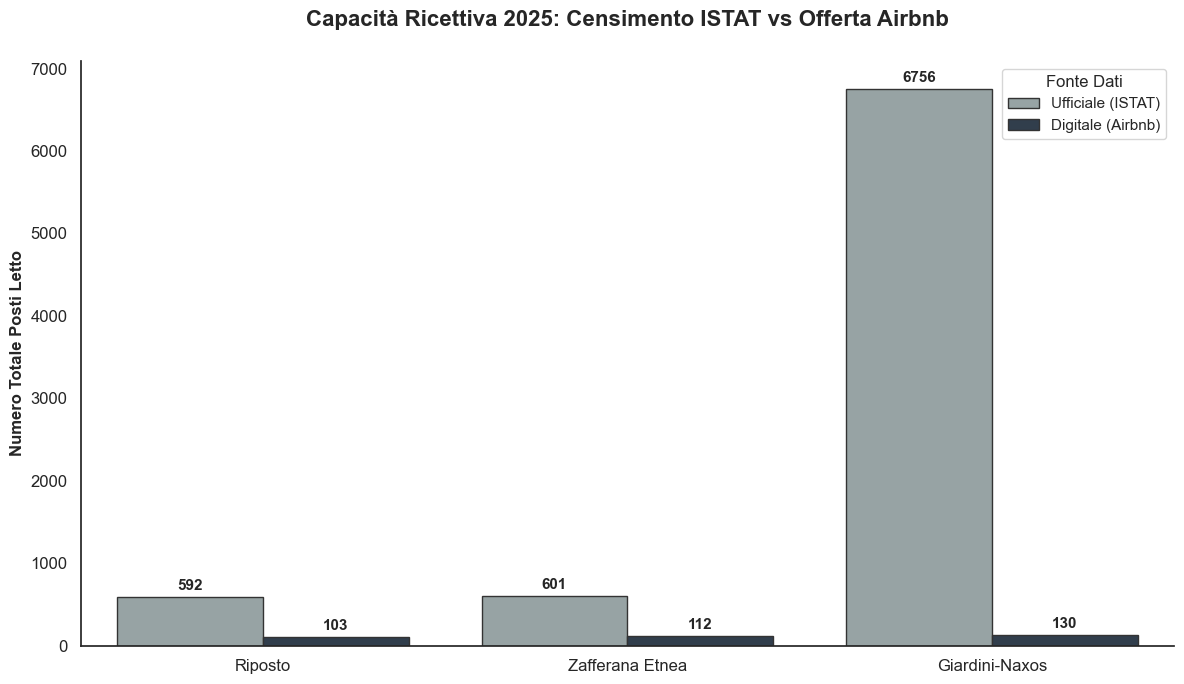

In [37]:
# 1. Calcoliamo la capacità totale (Posti Letto) dichiarata su Airbnb
airbnb_capacity = {
    'Riposto': riposto_df['accommodates'].sum(),
    'Giardini-Naxos': giardini_df['accommodates'].sum(),
    'Zafferana Etnea': zafferana_df['accommodates'].sum()
}

data_plot = [
    {'Comune': 'Riposto', 'Tipo': 'Ufficiale (ISTAT)', 'Posti Letto': 592},
    {'Comune': 'Riposto', 'Tipo': 'Digitale (Airbnb)', 'Posti Letto': airbnb_capacity['Riposto']},
    
    {'Comune': 'Zafferana Etnea', 'Tipo': 'Ufficiale (ISTAT)', 'Posti Letto': 601},
    {'Comune': 'Zafferana Etnea', 'Tipo': 'Digitale (Airbnb)', 'Posti Letto': airbnb_capacity['Zafferana Etnea']},
    
    {'Comune': 'Giardini-Naxos', 'Tipo': 'Ufficiale (ISTAT)', 'Posti Letto': 6756},
    {'Comune': 'Giardini-Naxos', 'Tipo': 'Digitale (Airbnb)', 'Posti Letto': airbnb_capacity['Giardini-Naxos']}
]

df_comparativo = pd.DataFrame(data_plot)

# 3. Visualizzazione: Grafico a Barre Raggruppate
plt.figure(figsize=(12, 7))
sns.set_style("white")

# Usiamo due colori sobri e istituzionali (es. Blu scuro e Grigio/Azzurro)
ax = sns.barplot(
    data=df_comparativo, 
    x='Comune', 
    y='Posti Letto', 
    hue='Tipo', 
    palette=['#95a5a6', '#2c3e50'], # Grigio per ISTAT, Blu scuro per Airbnb
    edgecolor='.2'
)

# 4. Aggiunta etichette sopra le barre
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.text(
            p.get_x() + p.get_width() / 2., 
            height + 50, # Un po' di spazio sopra
            f'{int(height)}', 
            ha='center', va='bottom', fontsize=11, fontweight='bold'
        )

# Titoli e Label
plt.title('Capacità Ricettiva 2025: Censimento ISTAT vs Offerta Airbnb', fontsize=16, fontweight='bold', pad=25)
plt.ylabel('Numero Totale Posti Letto', fontsize=12)
plt.xlabel('')
plt.legend(title='Fonte Dati')

# Nota: per Giardini la scala sarà molto alta, quindi mettiamo una scala logaritmica se necessario, 
# ma per ora lasciamola lineare per far vedere quanto Giardini sia "fuori scala"
sns.despine()
plt.tight_layout()
plt.show()

--- RAPPORTO DI INCIDENZA TRA RICETTIVITÀ UFFICIALE E DIGITALE ---
         Comune  Posti Letto ISTAT  Posti Letto Airbnb  Incidenza Digitale (%)  Delta Posti
Zafferana Etnea                601                 112                   18.64         -489
        Riposto                592                 103                   17.40         -489
 Giardini-Naxos               6756                 130                    1.92        -6626

    FOCUS STRATEGICO: IL SORPASSO DI RIPOSTO
Posti Letto Ufficiali (ISTAT): 592
Posti Letto Digitali (Airbnb): 103
---------------------------------------------
Indice di Incidenza Digitale:  17.4%
Differenziale Assoluto:        -489 posti


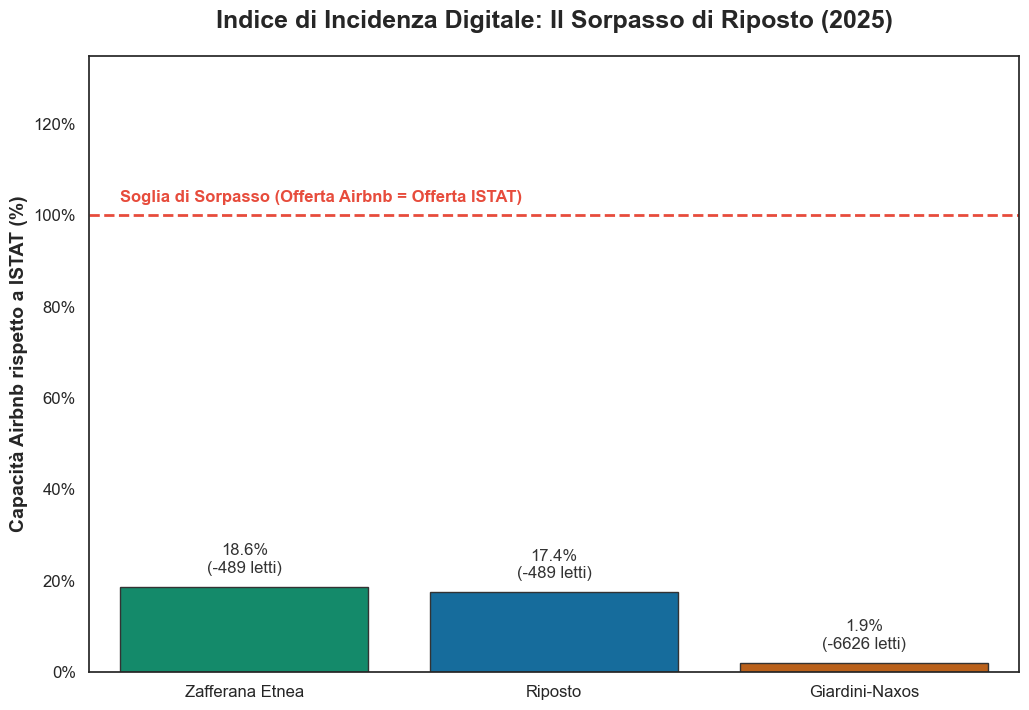

In [42]:
# 1. Creazione del DataFrame di confronto basato sulla capacità REALE (accommodates)
confronto_finale = pd.DataFrame([
    {'Comune': 'Riposto', 'Posti Letto ISTAT': 592, 'Posti Letto Airbnb': airbnb_capacity['Riposto']},
    {'Comune': 'Zafferana Etnea', 'Posti Letto ISTAT': 601, 'Posti Letto Airbnb': airbnb_capacity['Zafferana Etnea']},
    {'Comune': 'Giardini-Naxos', 'Posti Letto ISTAT': 6756, 'Posti Letto Airbnb': airbnb_capacity['Giardini-Naxos']}
])

# 2. Calcolo dell'Incidenza Digitale (Rapporto tra offerta digitale e ufficiale)
confronto_finale['Incidenza Digitale (%)'] = (confronto_finale['Posti Letto Airbnb'] / confronto_finale['Posti Letto ISTAT'] * 100).round(2)

# 3. Calcolo del Delta Assoluto (Posti in più o in meno rispetto all'ufficiale)
confronto_finale['Delta Posti'] = confronto_finale['Posti Letto Airbnb'] - confronto_finale['Posti Letto ISTAT']

# 4. Ordinamento per impatto digitale (Incidenza Decrescente)
confronto_finale = confronto_finale.sort_values(by='Incidenza Digitale (%)', ascending=False)

print("--- RAPPORTO DI INCIDENZA TRA RICETTIVITÀ UFFICIALE E DIGITALE ---")
print(confronto_finale.to_string(index=False))

# --- REPORT DI IMPATTO: IL CASO RIPOSTO ---
row_riposto = confronto_finale[confronto_finale['Comune'] == 'Riposto'].iloc[0]

print(f"\n{'='*45}")
print(f"    FOCUS STRATEGICO: IL SORPASSO DI RIPOSTO")
print(f"{'='*45}")
print(f"Posti Letto Ufficiali (ISTAT): {int(row_riposto['Posti Letto ISTAT'])}")
print(f"Posti Letto Digitali (Airbnb): {int(row_riposto['Posti Letto Airbnb'])}")
print(f"---------------------------------------------")
print(f"Indice di Incidenza Digitale:  {row_riposto['Incidenza Digitale (%)']}%")
print(f"Differenziale Assoluto:        {int(row_riposto['Delta Posti']):+} posti")
print(f"{'='*45}")

# --- Visualizzazione: Il Sorpasso Digitale (Incidenza %) ---
# Creiamo la figura usando l'approccio orientato agli oggetti per avere il controllo totale
fig, ax = plt.subplots(figsize=(12, 8))

# Usiamo la tua funzione globale per mappare i colori nel giusto ordine
current_palette = get_palette(confronto_finale['Comune'].tolist())

# Creazione del Barplot
sns.barplot(
    data=confronto_finale,
    x='Comune',
    y='Incidenza Digitale (%)',
    palette=current_palette,
    hue='Comune',
    legend=False,
    edgecolor='.2',
    ax=ax  # Forziamo Seaborn a usare questa figura esatta
)

# La "Linea di Sorpasso" (100% = Parità con ISTAT)
ax.axhline(100, color='#e74c3c', linestyle='--', linewidth=2, zorder=0)
ax.text(-0.4, 103, 'Soglia di Sorpasso (Offerta Airbnb = Offerta ISTAT)', 
         color='#e74c3c', fontweight='bold')

# Etichette doppie: Percentuale + Delta Assoluto
for p, delta in zip(ax.patches, confronto_finale['Delta Posti']):
    height = p.get_height()
    segno = '+' if delta > 0 else ''
    testo_etichetta = f"{height:.1f}%\n({segno}{int(delta)} letti)"
    
    ax.annotate(
        testo_etichetta,
        (p.get_x() + p.get_width() / 2., height),
        ha='center', va='bottom',
        xytext=(0, 8), textcoords='offset points',
        color='#333333'
    )

# Formattazione asse Y
ax.yaxis.set_major_formatter(ticker.PercentFormatter())

# IL TRUCCO: Questo aggiunge dinamicamente il 35% di spazio vuoto sopra la barra più alta
ax.margins(y=0.35)

# Titoli e Label assegnati direttamente all'asse
ax.set_title('Indice di Incidenza Digitale: Il Sorpasso di Riposto (2025)', pad=20)
ax.set_ylabel('Capacità Airbnb rispetto a ISTAT (%)')
ax.set_xlabel('')

# Disabilitiamo l'autolayout per prevenire il conflitto con rcParams
fig.set_layout_engine('none')

# Salvataggio: bbox_inches='tight' creerà l'immagine con le proporzioni perfette per il tuo report
fig.savefig('incidenza_digitale_sorpasso.png', dpi=300, bbox_inches='tight')
plt.show()

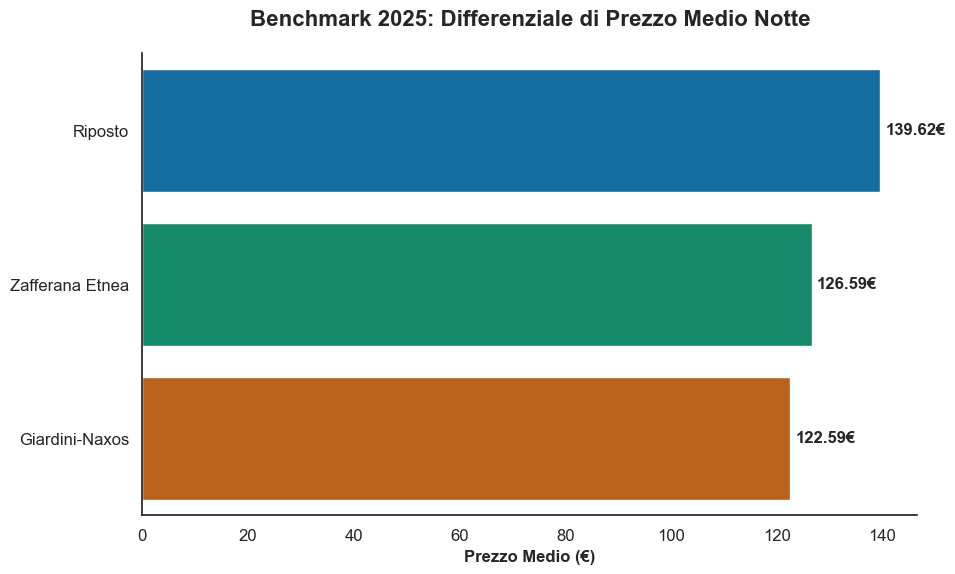

DATI DI SINTESI DEL BENCHMARK:
            Comune  Prezzo Medio  Revenue Annuo Medio  Densità Alloggi
0          Riposto        139.62             24635.85               33
2  Zafferana Etnea        126.59             28625.24               31
1   Giardini-Naxos        122.59             24004.91               36


In [39]:
comp_data = []

for nome, df_city in [('Riposto', riposto_df), ('Giardini-Naxos', giardini_df),  ('Zafferana Etnea', zafferana_df)]:
    comp_data.append({
        'Comune': nome,
        'Prezzo Medio': df_city['price'].mean(),
        'Revenue Annuo Medio' : df_city['estimated_revenue_annuo'].mean(),
        'Densità Alloggi': len(df_city)
    })

df_confronto = pd.DataFrame(comp_data).sort_values(by = 'Prezzo Medio', ascending = False)

# Visualizzazione del Prezzo Medio
plt.figure(figsize = (10, 6))

# Palette nell'ordine corretto
current_palette = get_palette(df_confronto['Comune'])

ax = sns.barplot(x = 'Prezzo Medio', 
                 y = 'Comune',
                 data = df_confronto, 
                 palette = current_palette,
                 hue = 'Comune',
                 legend = False
)

# Labels
for i, v in enumerate(df_confronto['Prezzo Medio']):
    ax.text(v + 1, i ,f"{v:.2f}€", va = 'center', fontweight = 'bold', fontsize = 12)

plt.title('Benchmark 2025: Differenziale di Prezzo Medio Notte', fontsize = 16, fontweight = 'bold', pad = 20)
plt.xlabel('Prezzo Medio (€)', fontsize = 12)
plt.ylabel('')
sns.despine()
plt.savefig('benchmark_prezzi_comparati.png', dpi=300, bbox_inches='tight')
plt.show()

print("DATI DI SINTESI DEL BENCHMARK:")
print(df_confronto.round(2))

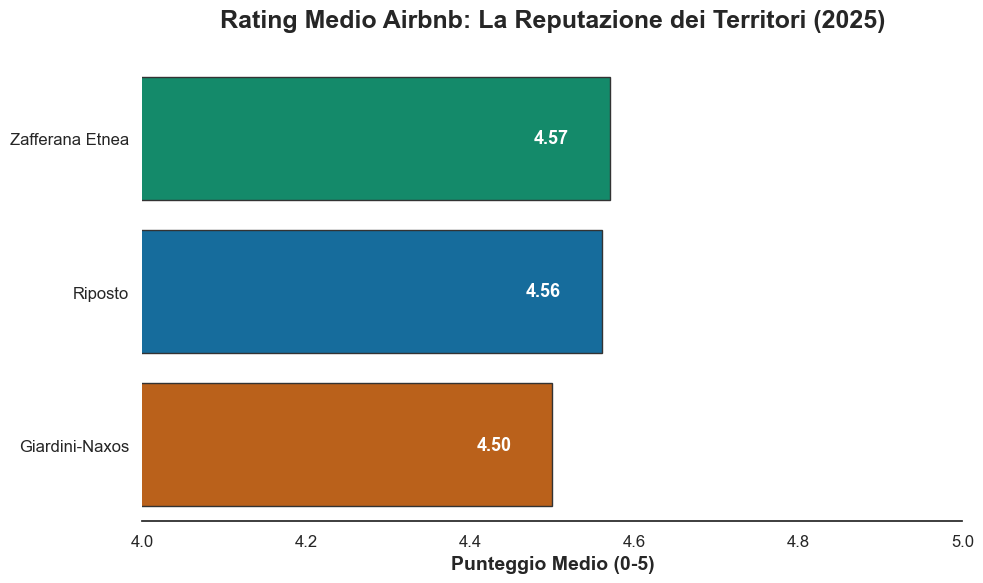

SINTESI REPUTAZIONE DIGITALE:
         Comune  Rating Medio
Zafferana Etnea          4.57
        Riposto          4.56
 Giardini-Naxos          4.50


In [40]:
plt.figure(figsize = (10,6))

# Preparazione dei dati per la Qualità (Escludiamo i NaN nelle recensioni)
qualita_data = []

for nome, df_city in [('Riposto', riposto_df), ('Giardini-Naxos', giardini_df), ('Zafferana Etnea', zafferana_df)]:
    # Prendiamo solo chi ha almeno una recensione per una media reale
    media_voto = df_city['review_scores_rating'].dropna().mean()
    qualita_data.append({
        'Comune': nome,
        'Rating Medio': round(media_voto, 2)
    })

df_qualita = pd.DataFrame(qualita_data).sort_values(by='Rating Medio', ascending=False)

# Visualizzazione (Zoom sui valori alti per vedere le micro-differenze)
current_palette = get_palette(df_qualita['Comune'])

ax = sns.barplot(
    x = 'Rating Medio',
    y = 'Comune',
    data = df_qualita,
    palette = current_palette,
    hue = 'Comune',
    legend=False,
    edgecolor = '.2'
)

# Etichette sulle barre
for i, v in enumerate(df_qualita['Rating Medio']):
    ax.text(
        v - 0.05, i, f"{v:.2f}",
        va='center',
        ha = 'right',
        fontweight = 'bold',
        fontsize = 13,
        color='white')

# TRUCCO TECNICO: Impostiamo il limite X tra 4 e 5 per evidenziare i distacchi
plt.xlim(4.0, 5.0)

plt.title('Rating Medio Airbnb: La Reputazione dei Territori (2025)', pad=25)
plt.xlabel('Punteggio Medio (0-5)')
plt.ylabel('')

sns.despine(left = True)
plt.tight_layout()

plt.savefig('reputazione_digitale_comparata.png', dpi = 300, bbox_inches = 'tight')

plt.show()

print("SINTESI REPUTAZIONE DIGITALE:")
print(df_qualita.to_string(index = False))